Notas técnicas sobre las librerías instaladas:
- **torch, torchvision:** Framework principal para construir y entrenar arquitecturas de Deep Learning (CNNs, RNNs, Transformers).
- **transformers:** API de Hugging Face para acceder a modelos pre-entrenados (BERT, RoBERTa, ViT, etc.) y pipelines de inferencia.
- **pillow:** Biblioteca fundamental para preprocesamiento y manipulación de imágenes antes de alimentar modelos de Computer Vision.
- **pandas, numpy:** Herramientas esenciales para la manipulación, limpieza y estructuración de datasets (estructuras tipo DataFrame/Arrays).
- **matplotlib:** Utilizado para la visualización de métricas de entrenamiento (curvas de pérdida/precisión) y análisis exploratorio de datos (EDA).
- **sentencepiece:** Tokenizador sub-palabra necesario para el preprocesamiento de texto en muchos modelos de la familia LLaMA, T5 y otros modelos auto-regresivos.sivos.

In [11]:
# Instalación de dependencias base para proyectos de Deep Learning y Procesamiento de Lenguaje Natural (NLP).
# Estas librerías conforman el stack tecnológico estándar para experimentación con modelos Transformer y visión artificial.
!pip install torch torchvision transformers pillow matplotlib pandas numpy sentencepiece


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import torch                                 # Framework principal para tensores y computación en GPU
from PIL import Image                        # Biblioteca para carga y manipulación de imágenes
import matplotlib.pyplot as plt              # Herramienta estándar para visualización de métricas
import pandas as pd                          # Manejo de estructuras de datos tabulares (DataFrames)
import numpy as np                           # Operaciones numéricas de alto rendimiento

# Cargar una imagen de prueba

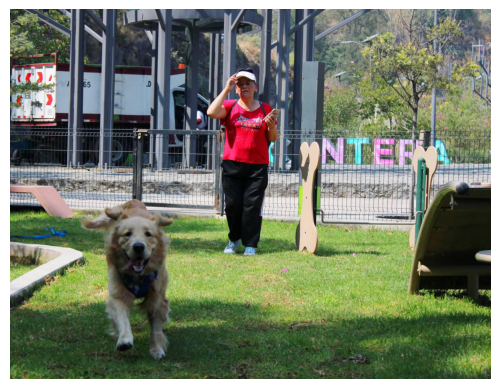

In [17]:
image_path = "imagenes_practica/perro_parque.jpg"      # Definición de la ruta al archivo de imagen
image = Image.open(image_path).convert("RGB")          # Carga la imagen y asegura formato de 3 canales (RGB)

# Configuración y despliegue de la imagen mediante la interfaz de matplotlib
plt.imshow(image)                                      # Renderiza el array de la imagen en el canvas
plt.axis("off")                                        # Oculta los ejes cartesianos para una visualización limpia
plt.show()                                             # Muestra el resultado final en el entorno de ejecución

# Arquitectura CNN + RNN para Image Captioning

**VisionEncoderDecoderModel:** Clase base para arquitecturas que  combinan un encoder de visión (ej. ViT) con un decoder de lenguaje.

**ViTImageProcessor:** Preprocesador específico para normalizar y  redimensionar imágenes para el Vision Transformer.

**AutoTokenizer:** Tokenizador pre-configurado para procesar las  salidas textuales del decodificador.

In [23]:
# Importación de componentes clave para tareas de "Image Captioning" o codificación-decodificación multimodal.
from transformers import VisionEncoderDecoderModel, \
    ViTImageProcessor, AutoTokenizer

In [24]:
# Detecta si hay una GPU disponible para acelerar los cálculos; si no, utiliza la CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Retorna el dispositivo seleccionado, esencial para mover los tensores y el modelo al hardware adecuado
device

'cpu'

In [27]:
model_name = "nlpconnect/vit-gpt2-image-captioning" # Especifica el repositorio del modelo pre-entrenado

# Carga la arquitectura completa (Encoder-Decoder) y transfiérela a la memoria del dispositivo (GPU/CPU)
caption_model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)

# Inicializa el procesador de imágenes asociado al modelo para manejar el redimensionamiento y normalización
caption_processor = ViTImageProcessor.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

C:\Users\LENOVO\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--nlpconnect--vit-gpt2-image-captioning. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

In [28]:
# Inicializa el tokenizador correspondiente al modelo (GPT-2) para convertir texto a tokens y viceversa
caption_tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [35]:
def generar_caption_transformer_basico(image):
    '''Genera un caption para una imagen utilizando un modelo transformer básico.'''
    # Preprocesa la imagen a tensores, moviéndolos al dispositivo (GPU/CPU) para el modelo
    pixel_values = caption_processor(images = image, return_tensors="pt").pixel_values.to(device)
    
    # Ejecuta el proceso de generación autoregresiva con beam search para mayor precisión
    output_ids = caption_model.generate(
        pixel_values,
        max_length = 20,           # Define el límite superior de tokens en la secuencia generada
        num_beams = 4              # Número de haces para explorar alternativas y mejorar la calidad del texto
    )
    
    # Decodifica los tokens resultantes a texto legible, eliminando tokens especiales de inicio/fin
    caption = caption_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption

In [39]:
# Realiza la inferencia utilizando la función definida para obtener la descripción de la imagen cargada
caption_cnn_rnn = generar_caption_transformer_basico(image)

# Imprime el resultado en consola para verificar la precisión de la inferencia
print("Caption generado por el modelo transformer básico:", caption_cnn_rnn)

Caption generado por el modelo transformer básico: a woman standing next to a dog on a lawn 


In [45]:
from deep_translator import GoogleTranslator      # Biblioteca ligera para traducción vía API de Google

def generar_caption_en_espanol(image):            # Wrapper para traducir el resultado al vuelo
    caption_en = generar_caption_transformer_basico(image)
    # Traduce el caption generado del inglés al español
    return GoogleTranslator(source='en', target='es').translate(caption_en)

# Ejemplo de uso
caption_es = generar_caption_en_espanol(image)    # Obtiene la descripción traducida
print(f"Descripción en español: {caption_es}")    # Imprime el resultado en el nuevo idioma

Descripción en español: una mujer parada junto a un perro en el césped


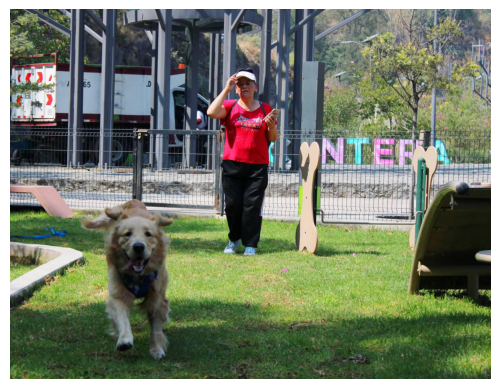

--- Imagen: imagenes_practica/perro_parque.jpg ---
Inglés: a woman standing next to a dog on a lawn 
Español: una mujer parada junto a un perro en el césped



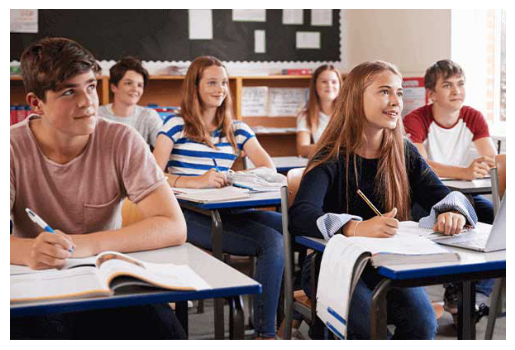

--- Imagen: imagenes_practica/aula_estudiantes.jpg ---
Inglés: a large group of people sitting at a table 
Español: un gran grupo de personas sentadas en una mesa



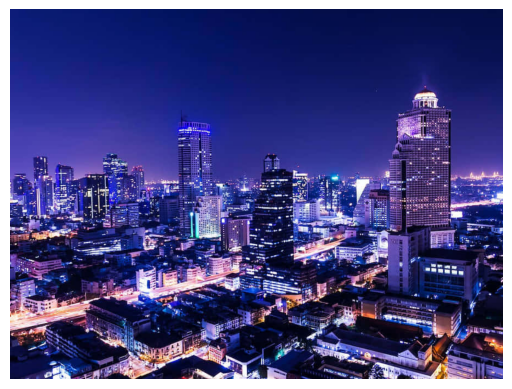

--- Imagen: imagenes_practica/ciudad_noche.jpg ---
Inglés: a city street filled with lots of traffic at night 
Español: Una calle de la ciudad llena de mucho tráfico por la noche.



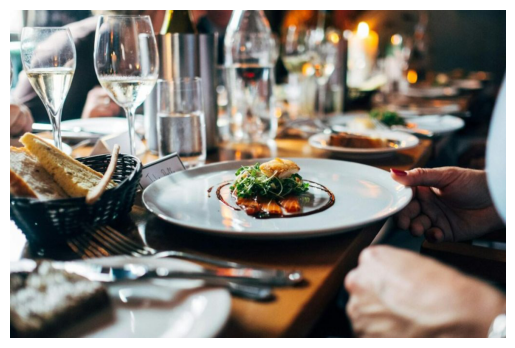

--- Imagen: imagenes_practica/comida_restaurante.jpg ---
Inglés: a table with plates of food on it 
Español: una mesa con platos de comida encima



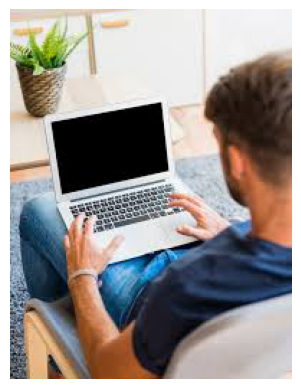

--- Imagen: imagenes_practica/persona_computadora.jpg ---
Inglés: a man sitting on a couch using a laptop computer 
Español: un hombre sentado en un sofá usando una computadora portátil



In [51]:
# Inicializa el traductor para el procesamiento
traductor = GoogleTranslator(source='en', target='es')

for path in imagenes:
    img = Image.open(path).convert("RGB")             # Carga y normaliza la imagen
    
    # Visualización inmediata de la imagen procesada
    plt.imshow(img)                                   # Muestra la imagen en el canvas
    plt.axis("off")                                   # Elimina ejes para mejor estética
    plt.show()                                        # Renderiza la imagen
    
    # Generación y traducción de descripciones
    caption_en = generar_caption_transformer_basico(img) 
    caption_es = traductor.translate(caption_en)      
    
    # Impresión de resultados en tiempo real
    print(f"--- Imagen: {path} ---")
    print(f"Inglés: {caption_en}")
    print(f"Español: {caption_es}\n")
    
    # Almacenamiento en la lista para el CSV final
    resultados.append({"imagen": path, "caption_en": caption_en, "caption_es": caption_es})
    
# Exportación del archivo final
df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv("captions_transformer_es.csv", index=False)

# Arquitectura de transformers para Image Captioning

**BlipProcessor:** Encargado de transformar imágenes y texto al formato requerido por el modelo pre-entrenado.

**BlipForConditionalGeneration:** Arquitectura unificada que permite generar texto condicionado al input visual.

In [55]:
# Importación de componentes de Salesforce BLIP (Bootstrapping Language-Image Pre-training)
# BLIP es altamente eficiente para tareas de Image Captioning y VQA (Visual Question Answering)

from transformers import BlipProcessor, \
    BlipForConditionalGeneration

In [57]:
# Define el checkpoint del modelo BLIP base, optimizado para una alta relación calidad-velocidad
blip_name = "Salesforce/blip-image-captioning-base"

In [59]:
# Inicializa el procesador de BLIP para manejar la tokenización y normalización de la imagen
blip_processor = BlipProcessor.from_pretrained(blip_name)

# Carga el modelo BLIP configurado para generación y muévelo al dispositivo (GPU/CPU)
blip_model = BlipForConditionalGeneration.from_pretrained(blip_name).to(device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

C:\Users\LENOVO\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

In [60]:
def generar_caption_blip(image):
    '''Genera un caption para una imagen usando un modelo BLIP.'''
    # Procesa la imagen y la mueve al dispositivo; **inputs desempaqueta las claves de tensores
    inputs = blip_processor(image, return_tensors="pt").to(device)
    
    # Genera la secuencia de tokens con una longitud máxima definida por max_new_tokens
    output_ids = blip_model.generate(
        **inputs,
        max_new_tokens = 30
    )
    
    # Decodifica los IDs de salida a texto, ignorando tokens especiales de control
    caption = blip_processor.decode(output_ids[0], skip_special_tokens=True)
    
    return caption

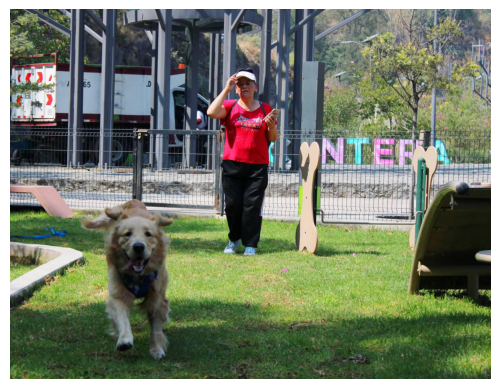

In [65]:
# Configuración y despliegue de la imagen mediante la interfaz de matplotlib
plt.imshow(image)                                      # Renderiza el array de la imagen en el canvas
plt.axis("off")                                        # Oculta los ejes cartesianos para una visualización limpia
plt.show()                                             # Muestra el resultado final en el entorno de ejecución

In [63]:
# Ejecuta la inferencia utilizando la arquitectura BLIP, altamente eficiente en tareas multimodales
caption_transformer = generar_caption_blip(image)

# Imprime el resultado en consola para comparar la calidad descriptiva respecto al modelo anterior
print("\nCaption generado por el modelo BLIP:", caption_transformer)


Caption generado por el modelo BLIP: a woman walking a dog


In [67]:
# Inicialización del traductor para procesar las salidas de BLIP
traductor = GoogleTranslator(source='en', target='es')

# Lista para consolidar los resultados de BLIP con traducciones
resultados_blip = []

for path in imagenes:
    img = Image.open(path).convert("RGB")             # Carga y estandariza la imagen a RGB
    caption_en = generar_caption_blip(img)            # Genera caption original en inglés (BLIP)
    caption_es = traductor.translate(caption_en)      # Traduce el caption al español
    
    # Registro del par imagen-descripciones en el dataset de resultados
    resultados_blip.append({
        "imagen": path, 
        "caption_blip_en": caption_en, 
        "caption_blip_es": caption_es
    })
    
# Estructuración de datos para comparativa final
df_resultados_blip = pd.DataFrame(resultados_blip)    # Conversión a DataFrame tabular
df_resultados_blip.to_csv("captions_blip_es.csv", index=False) # Exportación a CSV

# Despliegue del resultado final
df_resultados_blip

,imagen,caption_blip_en,caption_blip_es
0,imagenes_practica/perro_parque.jpg,a woman walking a dog,una mujer paseando a un perro
1,imagenes_practica/aula_estudiantes.jpg,students in a classroom,estudiantes en un salón de clases
2,imagenes_practica/ciudad_noche.jpg,bangkok cityscapeat night,paisaje urbano de bangkok por la noche
3,imagenes_practica/comida_restaurante.jpg,people eating at a restaurant,gente comiendo en un restaurante
4,imagenes_practica/persona_computadora.jpg,man sitting on a couch,hombre sentado en un sofá


# Arquitectura CLIP para Image Captioning

**CLIPProcessor:** Preprocesa imágenes y texto para que sean compatibles con el espacio latente del modelo.

**CLIPModel:** Modelo base que permite realizar tareas de "Zero-shot classification" y búsqueda semántica.

In [73]:
# Importación de componentes de OpenAI CLIP (Contrastive Language-Image Pre-training)
# CLIP permite medir la similitud entre imágenes y textos en un mismo espacio vectorial

from transformers import CLIPProcessor, \
    CLIPModel

In [75]:
# Define el checkpoint de CLIP (base) con parches de 32x32, balance equilibrado entre velocidad y precisión
clip_name = "openai/clip-vit-base-patch32"

# Carga la arquitectura del modelo y lo traslada a la memoria del dispositivo (GPU/CPU)
clip_model = CLIPModel.from_pretrained(clip_name).to(device)

# Inicializa el procesador que normaliza imágenes y tokeniza texto para el espacio vectorial conjunto
clip_processor = CLIPProcessor.from_pretrained(clip_name)

config.json: 0.00B [00:00, ?B/s]

C:\Users\LENOVO\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [76]:
def seleccionar_caption_con_clip(image, captions):
    '''Selecciona el caption más relevante para una imagen utilizando CLIP.'''
    # Preprocesa imagen y lista de textos al espacio vectorial de CLIP, enviándolos al dispositivo
    inputs = clip_processor(
        text = captions,
        images = image,
        return_tensors = "pt",
        padding = True
    ).to(device)
    
    # Realiza la inferencia del modelo para obtener los embeddings y el producto escalar
    outputs = clip_model(**inputs)
    
    # Extrae los logits de similitud (imagen vs. cada texto) y aplica Softmax para obtener probabilidades
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)
    
    # Identifica el índice del caption con la mayor probabilidad de correspondencia semántica
    mejor_indice = probs.argmax().item()
    
    # Retorna el texto ganador y el array completo de probabilidades para análisis posterior
    return captions[mejor_indice], probs.detach().cpu().numpy()[0]

In [79]:
# Lista de descripciones candidatas que serán evaluadas por su pertinencia semántica respecto a la imagen
caption_candidatos = [
    "A group of students in a classroom",
    "A dog running in a park",
    "A person driving a motorcycle",
    "A plate of food on a restaurant table",
    "A city skyline at night",
    "A car driving on a highway",
    "A person working on a computer"
]

# Ejecuta la selección basada en similitud coseno (vía CLIP) para encontrar el texto que mejor describe la imagen
mejor_caption, probabilidades = seleccionar_caption_con_clip(image, caption_candidatos)

# Imprime el resultado con mayor correlación visual hallado por el modelo
print("\nCaption seleccionado por CLIP:", mejor_caption)


Caption seleccionado por CLIP: A dog running in a park


In [81]:
# Itera sobre cada par de caption y su probabilidad correspondiente para analizar la confianza del modelo
for caption, prob in zip(caption_candidatos, probabilidades):
    # Imprime la relevancia de cada candidato, lo cual ayuda a visualizar la distribución de certidumbre de CLIP
    print(f"Caption: '{caption}' - Probabilidad de relevancia: {prob:.4f}")

Caption: 'A group of students in a classroom' - Probabilidad de relevancia: 0.0001
Caption: 'A dog running in a park' - Probabilidad de relevancia: 0.9998
Caption: 'A person driving a motorcycle' - Probabilidad de relevancia: 0.0000
Caption: 'A plate of food on a restaurant table' - Probabilidad de relevancia: 0.0000
Caption: 'A city skyline at night' - Probabilidad de relevancia: 0.0000
Caption: 'A car driving on a highway' - Probabilidad de relevancia: 0.0000
Caption: 'A person working on a computer' - Probabilidad de relevancia: 0.0001


In [83]:
# Inicialización de lista para registrar los resultados de la selección semántica mediante CLIP
resultados_clip = []

# Iteración por cada imagen del dataset para encontrar el caption más preciso mediante CLIP
for path in imagenes:
    img = Image.open(path).convert("RGB")             # Carga y estandariza cada imagen a formato RGB
    
    # Selecciona la mejor descripción del pool de candidatos y extrae el vector de probabilidades
    mejor_caption, probabilidades = seleccionar_caption_con_clip(img, caption_candidatos)
    
    # Registro del mejor candidato y su score de confianza (probabilidad máxima)
    resultados_clip.append({
        "imagen": path,
        "mejor_caption": mejor_caption,
        "probabilidad_maxima": float(np.max(probabilidades)) # Convierte a float nativo para el DataFrame
    })
    
# Estructuración y exportación del análisis de relevancia a formato tabular
df_resultados_clip = pd.DataFrame(resultados_clip)    # Conversión de la lista de resultados a DataFrame
df_resultados_clip.to_csv("captions_clip.csv", index=False) # Guardado de resultados sin índices en disco

# Despliegue del reporte consolidado de CLIP para validación técnica
df_resultados_clip

,imagen,mejor_caption,probabilidad_maxima
0,imagenes_practica/perro_parque.jpg,A dog running in a park,0.999848
1,imagenes_practica/aula_estudiantes.jpg,A group of students in a classroom,0.999960
2,imagenes_practica/ciudad_noche.jpg,A city skyline at night,0.999990
3,imagenes_practica/comida_restaurante.jpg,A plate of food on a restaurant table,0.999975
4,imagenes_practica/persona_computadora.jpg,A person working on a computer,0.998417


# Comparación de resultados

In [87]:
# Consolida los resultados de los tres métodos (ViT-GPT2, BLIP y Selección por CLIP) en un único dataset
# Nota: La concatenación vertical requiere que las columnas sean consistentes entre los DataFrames.
df_comparacion = pd.concat([df_resultados, df_resultados_blip, df_resultados_clip], ignore_index=True)

# Exporta la tabla maestra resultante para análisis posterior en herramientas de visualización o Excel
df_comparacion.to_csv("comparacion_captions.csv", index=False)

# Despliega el DataFrame consolidado para inspección visual de las diferencias entre modelos
df_comparacion

,imagen,caption_en,caption_es,caption_blip_en,caption_blip_es,mejor_caption,probabilidad_maxima
0,imagenes_practica/perro_parque.jpg,a woman standing next to a dog on a lawn,una mujer parada junto a un perro en el césped,NaN,NaN,NaN,NaN
1,imagenes_practica/aula_estudiantes.jpg,a large group of people sitting at a table,un gran grupo de personas sentadas en una mesa,NaN,NaN,NaN,NaN
2,imagenes_practica/ciudad_noche.jpg,a city street filled with lots of traffic at n...,Una calle de la ciudad llena de mucho tráfico ...,NaN,NaN,NaN,NaN
3,imagenes_practica/comida_restaurante.jpg,a table with plates of food on it,una mesa con platos de comida encima,NaN,NaN,NaN,NaN
4,imagenes_practica/persona_computadora.jpg,a man sitting on a couch using a laptop computer,un hombre sentado en un sofá usando una comput...,NaN,NaN,NaN,NaN
5,imagenes_practica/perro_parque.jpg,a woman standing next to a dog on a lawn,una mujer parada junto a un perro en el césped,NaN,NaN,NaN,NaN
6,imagenes_practica/aula_estudiantes.jpg,a large group of people sitting at a table,un gran grupo de personas sentadas en una mesa,NaN,NaN,NaN,NaN
7,imagenes_practica/ciudad_noche.jpg,a city street filled with lots of traffic at n...,Una calle de la ciudad llena de mucho tráfico ...,NaN,NaN,NaN,NaN
8,imagenes_practica/comida_restaurante.jpg,a table with plates of food on it,una mesa con platos de comida encima,NaN,NaN,NaN,NaN
9,imagenes_practica/persona_computadora.jpg,a man sitting on a couch using a laptop computer,un hombre sentado en un sofá usando una comput...,NaN,NaN,NaN,NaN
